In [1]:
# ==========================================================
# CELL 1: IMPORT LIBRARIES

# Import standard libraries
import warnings
import re
from pathlib import Path

# Import data manipulation libraries
import numpy as np
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scikit-Learn modules
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Configure display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 150)

# Configure plotting
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

# Suppress warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("Libraries Imported Successfully")
print("=" * 70)

Libraries Imported Successfully


In [2]:
# ==========================================================
# CELL 2: LOAD DATASET

# Dataset path
dataset_path = Path(
    r"C:\Users\bts\OneDrive\Desktop\Auspify\Dataset\clean_netflix_dataset.csv"
)

# Verify dataset exists
if not dataset_path.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{dataset_path}"
    )

# Load dataset
df = pd.read_csv(dataset_path)

print("=" * 70)
print("Dataset Loaded Successfully")
print("=" * 70)

print(f"Dataset Shape : {df.shape}")

print("\nFirst Five Rows")
display(df.head())

print("\nLast Five Rows")
display(df.tail())

Dataset Loaded Successfully
Dataset Shape : (8790, 18)

First Five Rows


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,release_year_year,release_year_month,release_year_day,content_age,duration_category
0,S1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,1970-01-01 00:00:00.000002020,Pg-13,90 Min,Documentaries,2021,9,25,1970,1,1,56,Medium
1,S3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,1970-01-01 00:00:00.000002021,Tv-Ma,1 Season,"Crime Tv Shows, International Tv Shows, Tv Action & Adventure",2021,9,24,1970,1,1,56,Short
2,S6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,1970-01-01 00:00:00.000002021,Tv-Ma,1 Season,"Tv Dramas, Tv Horror, Tv Mysteries",2021,9,24,1970,1,1,56,Short
3,S14,Movie,Confessions Of An Invisible Girl,Bruno Garotti,Brazil,2021-09-22,1970-01-01 00:00:00.000002021,Tv-Pg,91 Min,"Children & Family Movies, Comedies",2021,9,22,1970,1,1,56,Medium
4,S8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1970-01-01 00:00:00.000001993,Tv-Ma,125 Min,"Dramas, Independent Movies, International Movies",2021,9,24,1970,1,1,56,Long



Last Five Rows


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_day,release_year_year,release_year_month,release_year_day,content_age,duration_category
8785,S8797,Tv Show,Yunus Emre,Not Given,Turkey,2017-01-17,1970-01-01 00:00:00.000002016,Tv-Pg,2 Seasons,"International Tv Shows, Tv Dramas",2017,1,17,1970,1,1,56,Short
8786,S8798,Tv Show,Zak Storm,Not Given,United States,2018-09-13,1970-01-01 00:00:00.000002016,Tv-Y7,3 Seasons,Kids Tv,2018,9,13,1970,1,1,56,Short
8787,S8801,Tv Show,Zindagi Gulzar Hai,Not Given,Pakistan,2016-12-15,1970-01-01 00:00:00.000002012,Tv-Pg,1 Season,"International Tv Shows, Romantic Tv Shows, Tv Dramas",2016,12,15,1970,1,1,56,Short
8788,S8784,Tv Show,Yoko,Not Given,Pakistan,2018-06-23,1970-01-01 00:00:00.000002016,Tv-Y,1 Season,Kids Tv,2018,6,23,1970,1,1,56,Short
8789,S8786,Tv Show,Yom,Not Given,Pakistan,2018-06-07,1970-01-01 00:00:00.000002016,Tv-Y7,1 Season,Kids Tv,2018,6,7,1970,1,1,56,Short


In [3]:
# ==========================================================
# CELL 3: DATASET OVERVIEW

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

df.info()

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

display(df.describe(include="all").T)

print("\n" + "=" * 70)
print("COLUMN NAMES")
print("=" * 70)

for column in df.columns:
    print(column)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame(name="Missing Values")
)

display(missing)

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   show_id             8790 non-null   str  
 1   type                8790 non-null   str  
 2   title               8790 non-null   str  
 3   director            8790 non-null   str  
 4   country             8790 non-null   str  
 5   date_added          8790 non-null   str  
 6   release_year        8790 non-null   str  
 7   rating              8790 non-null   str  
 8   duration            8790 non-null   str  
 9   listed_in           8790 non-null   str  
 10  date_added_year     8790 non-null   int64
 11  date_added_month    8790 non-null   int64
 12  date_added_day      8790 non-null   int64
 13  release_year_year   8790 non-null   int64
 14  release_year_month  8790 non-null   int64
 15  release_year_day    8790 non-null   int64
 16  content_age         8790 non-null

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8790,8790,S1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8790,2,Movie,6126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8790,8781,Love In A Puff,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8790,4526,Not Given,2588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8790,86,United States,3240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8790,1713,2020-01-01,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8790,74,1970-01-01 00:00:00.000002018,1146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,8790,14,Tv-Ma,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8790,220,1 Season,1791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,8790,513,"Dramas, International Movies",362,NaN,NaN,NaN,NaN,NaN,NaN,NaN



COLUMN NAMES
show_id
type
title
director
country
date_added
release_year
rating
duration
listed_in
date_added_year
date_added_month
date_added_day
release_year_year
release_year_month
release_year_day
content_age
duration_category

MISSING VALUES


,Missing Values
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [4]:
# ==========================================================
# CELL 4: SELECT IMPORTANT FEATURES

# Automatically detect relevant columns

possible_columns = {
    "title": ["title", "name"],
    "listed_in": ["listed_in", "genre", "genres", "category"],
    "description": ["description", "overview", "summary"],
    "director": ["director"],
    "cast": ["cast", "actors"],
    "country": ["country"],
    "rating": ["rating"],
    "type": ["type"],
    "duration": ["duration"],
    "release_year": ["release_year", "year"]
}

selected_columns = {}

dataset_columns = [col.lower() for col in df.columns]

for feature, aliases in possible_columns.items():

    found = None

    for alias in aliases:

        for actual in df.columns:

            if actual.lower() == alias:
                found = actual
                break

        if found:
            break

    if found:
        selected_columns[feature] = found

print("=" * 70)
print("DETECTED FEATURES")
print("=" * 70)

for key, value in selected_columns.items():
    print(f"{key:<15} --> {value}")

# Create working dataframe

working_df = df[
    list(selected_columns.values())
].copy()

# Fill missing values safely

working_df = working_df.fillna("Unknown")

print("\nWorking Dataset Shape :", working_df.shape)

display(working_df.head())

DETECTED FEATURES
title           --> title
listed_in       --> listed_in
director        --> director
country         --> country
rating          --> rating
type            --> type
duration        --> duration
release_year    --> release_year

Working Dataset Shape : (8790, 8)


,title,listed_in,director,country,rating,type,duration,release_year
0,Dick Johnson Is Dead,Documentaries,Kirsten Johnson,United States,Pg-13,Movie,90 Min,1970-01-01 00:00:00.000002020
1,Ganglands,"Crime Tv Shows, International Tv Shows, Tv Action & Adventure",Julien Leclercq,France,Tv-Ma,Tv Show,1 Season,1970-01-01 00:00:00.000002021
2,Midnight Mass,"Tv Dramas, Tv Horror, Tv Mysteries",Mike Flanagan,United States,Tv-Ma,Tv Show,1 Season,1970-01-01 00:00:00.000002021
3,Confessions Of An Invisible Girl,"Children & Family Movies, Comedies",Bruno Garotti,Brazil,Tv-Pg,Movie,91 Min,1970-01-01 00:00:00.000002021
4,Sankofa,"Dramas, Independent Movies, International Movies",Haile Gerima,United States,Tv-Ma,Movie,125 Min,1970-01-01 00:00:00.000001993


In [5]:
# ==========================================================
# CELL 5: TEXT CLEANING

# Reusable preprocessing function

def clean_text(text):
    """
    Clean textual information for NLP processing.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()


print("=" * 70)
print("TEXT CLEANING FUNCTION CREATED")
print("=" * 70)

# Demonstration

sample_text = "Netflix Movie 2024!! Directed by Steven Spielberg."

print("Original :")
print(sample_text)

print("\nProcessed :")
print(clean_text(sample_text))

TEXT CLEANING FUNCTION CREATED
Original :
Netflix Movie 2024!! Directed by Steven Spielberg.

Processed :
netflix movie directed by steven spielberg


In [6]:
# ==========================================================
# CELL 6: FEATURE ENGINEERING

# Select metadata columns for recommendation

metadata_columns = [
    column
    for column in [
        selected_columns.get("listed_in"),
        selected_columns.get("description"),
        selected_columns.get("director"),
        selected_columns.get("cast"),
        selected_columns.get("country"),
        selected_columns.get("rating"),
        selected_columns.get("type"),
        selected_columns.get("duration"),
        selected_columns.get("release_year")
    ]
    if column is not None
]

print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

print("Metadata Columns Used")

for col in metadata_columns:
    print("-", col)

# Combine metadata into one feature

working_df["combined_features"] = working_df[
    metadata_columns
].astype(str).agg(" ".join, axis=1)

display(
    working_df[
        ["combined_features"]
    ].head()
)

FEATURE ENGINEERING
Metadata Columns Used
- listed_in
- director
- country
- rating
- type
- duration
- release_year


,combined_features
0,Documentaries Kirsten Johnson United States Pg-13 Movie 90 Min 1970-01-01 00:00:00.000002020
1,"Crime Tv Shows, International Tv Shows, Tv Action & Adventure Julien Leclercq France Tv-Ma Tv Sh..."
2,"Tv Dramas, Tv Horror, Tv Mysteries Mike Flanagan United States Tv-Ma Tv Show 1 Season 1970-01-01..."
3,"Children & Family Movies, Comedies Bruno Garotti Brazil Tv-Pg Movie 91 Min 1970-01-01 00:00:00.0..."
4,"Dramas, Independent Movies, International Movies Haile Gerima United States Tv-Ma Movie 125 Min ..."


In [7]:
# ==========================================================
# CELL 7: TEXT PREPROCESSING

print("=" * 70)
print("TEXT PREPROCESSING")
print("=" * 70)

# Apply cleaning function

working_df["processed_text"] = (
    working_df["combined_features"]
    .apply(clean_text)
)

print("Processed Corpus Generated Successfully")

print("\nSample Processed Text\n")

for i, text in enumerate(
    working_df["processed_text"].head(5),
    start=1
):
    print(f"{i}. {text[:200]}")
    print("-" * 60)

TEXT PREPROCESSING
Processed Corpus Generated Successfully

Sample Processed Text

1. documentaries kirsten johnson united states pg movie min
------------------------------------------------------------
2. crime tv shows international tv shows tv action adventure julien leclercq france tv ma tv show season
------------------------------------------------------------
3. tv dramas tv horror tv mysteries mike flanagan united states tv ma tv show season
------------------------------------------------------------
4. children family movies comedies bruno garotti brazil tv pg movie min
------------------------------------------------------------
5. dramas independent movies international movies haile gerima united states tv ma movie min
------------------------------------------------------------


In [8]:
# ==========================================================
# CELL 8: TF-IDF VECTORIZATION

print("=" * 70)
print("TF-IDF VECTORIZATION")
print("=" * 70)

# Initialize vectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

# Transform text

tfidf_matrix = tfidf.fit_transform(
    working_df["processed_text"]
)

# Vocabulary

feature_names = tfidf.get_feature_names_out()

print(f"TF-IDF Matrix Shape : {tfidf_matrix.shape}")
print(f"Vocabulary Size     : {len(feature_names)}")

print("\nTop Vocabulary Sample")

print(feature_names[:30])

TF-IDF VECTORIZATION
TF-IDF Matrix Shape : (8790, 5000)
Vocabulary Size     : 5000

Top Vocabulary Sample
['aamir' 'aaron' 'aatmaram' 'abad' 'abba' 'abbas' 'abbasi' 'abbou' 'abby'
 'abdel' 'abdellatif' 'abdul' 'abdulaziz' 'abdullah' 'abdulsalam' 'abe'
 'abhijit' 'abhinay' 'abhishek' 'abraham' 'abrams' 'abu' 'action' 'adam'
 'adams' 'adetiba' 'adetuyi' 'adina' 'aditya' 'adri']


In [9]:
# ==========================================================
# CELL 9: COSINE SIMILARITY MATRIX

# Calculate cosine similarity between all Netflix titles

print("=" * 70)
print("CALCULATING COSINE SIMILARITY MATRIX")
print("=" * 70)

similarity_matrix = cosine_similarity(tfidf_matrix)

print(f"Similarity Matrix Shape : {similarity_matrix.shape}")

# Create title mapping
title_column = selected_columns.get("title")

title_to_index = {}

if title_column:
    for idx, title in enumerate(working_df[title_column]):
        title = str(title).strip()
        if title and title not in title_to_index:
            title_to_index[title] = idx

print(f"Indexed Titles : {len(title_to_index)}")

CALCULATING COSINE SIMILARITY MATRIX
Similarity Matrix Shape : (8790, 8790)
Indexed Titles : 8781


In [10]:
# ==========================================================
# CELL 10: BUILD RECOMMENDATION FUNCTION

def recommend_movies(title, top_n=10):
    """
    Recommend similar Netflix titles using
    TF-IDF + Cosine Similarity.
    """

    if not isinstance(title, str):
        print("Please provide a valid movie title.")
        return pd.DataFrame()

    title = title.strip()

    if title == "":
        print("Movie title cannot be empty.")
        return pd.DataFrame()

    if title not in title_to_index:
        print(f'"{title}" not found in dataset.')
        return pd.DataFrame()

    index = title_to_index[title]

    similarity_scores = list(
        enumerate(similarity_matrix[index])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1: top_n + 1]

    movie_indices = [i[0] for i in similarity_scores]
    scores = [i[1] for i in similarity_scores]

    recommendations = working_df.iloc[movie_indices].copy()

    recommendations["Similarity Score"] = np.round(scores, 4)

    columns_to_show = [title_column]

    if selected_columns.get("listed_in"):
        columns_to_show.append(selected_columns["listed_in"])

    recommendations = recommendations[
        columns_to_show + ["Similarity Score"]
    ]

    return recommendations.reset_index(drop=True)


print("Recommendation function created successfully.")

Recommendation function created successfully.


In [11]:
# ==========================================================
# CELL 11: TEST RECOMMENDATIONS

print("=" * 70)
print("TESTING RECOMMENDATION ENGINE")
print("=" * 70)

sample_titles = []

if title_column:

    sample_titles = (
        working_df[title_column]
        .dropna()
        .astype(str)
        .unique()[:3]
    )

for movie in sample_titles:

    print("\n" + "=" * 70)
    print(f"Recommendations for: {movie}")
    print("=" * 70)

    result = recommend_movies(movie, top_n=5)

    if not result.empty:
        display(result)

TESTING RECOMMENDATION ENGINE

Recommendations for: Dick Johnson Is Dead


,title,listed_in,Similarity Score
0,S.W.A.T.,Action & Adventure,0.4119
1,Kung Fu Panda: Holiday,"Children & Family Movies, Comedies",0.4084
2,Nova: Killer Floods,Documentaries,0.3843
3,She Did That,Documentaries,0.3843
4,The Debt Collector 2,Action & Adventure,0.3837



Recommendations for: Ganglands


,title,listed_in,Similarity Score
0,Sentinelle,"Action & Adventure, Dramas, International Movies",0.8329
1,Earth And Blood,"Dramas, International Movies, Thrillers",0.7602
2,Crime Time,"Crime Tv Shows, International Tv Shows, Tv Action & Adventure",0.6942
3,Lupin,"Crime Tv Shows, International Tv Shows, Tv Action & Adventure",0.6499
4,Ad Vitam,"Crime Tv Shows, International Tv Shows, Tv Dramas",0.6290



Recommendations for: Midnight Mass


,title,listed_in,Similarity Score
0,Geralds Game,"Horror Movies, Thrillers",0.7852
1,Hush,"Horror Movies, Thrillers",0.7366
2,Before I Wake,"Horror Movies, Thrillers",0.7201
3,Brand New Cherry Flavor,"Tv Dramas, Tv Horror, Tv Mysteries",0.6828
4,The Haunting Of Bly Manor,"Tv Dramas, Tv Horror, Tv Mysteries",0.6828


SIMILARITY HEATMAP


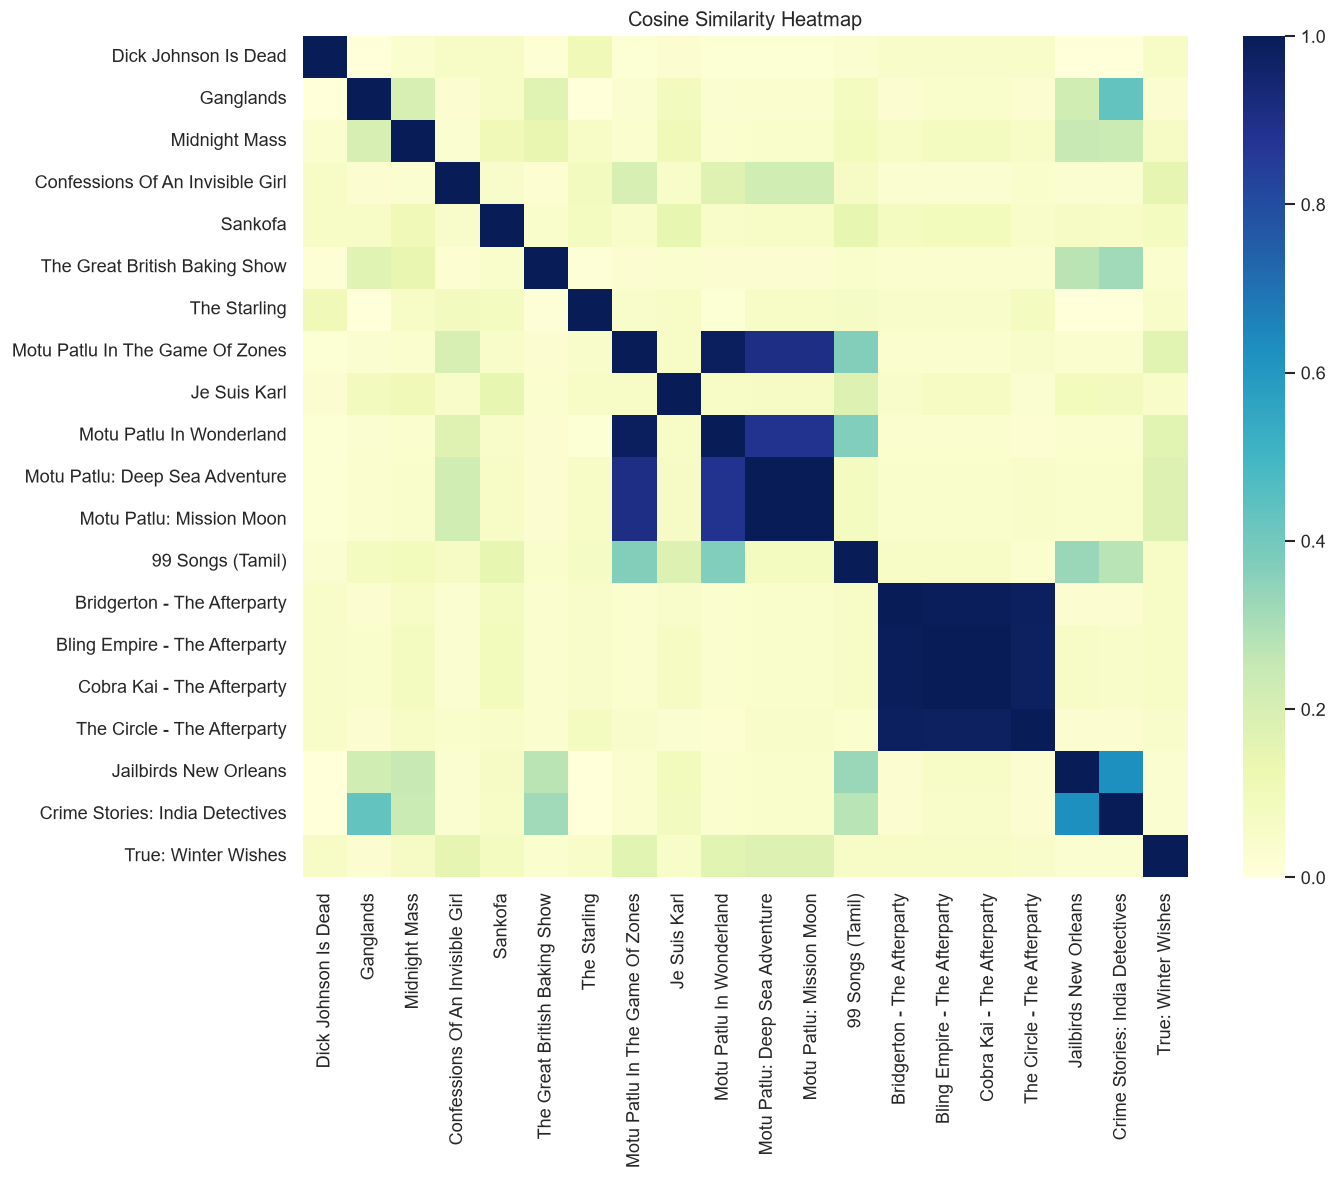

In [12]:
# ==========================================================
# CELL 12: VISUALIZE SIMILARITY

print("=" * 70)
print("SIMILARITY HEATMAP")
print("=" * 70)

sample_size = min(20, len(working_df))

heatmap_data = similarity_matrix[:sample_size, :sample_size]

labels = (
    working_df[title_column]
    .iloc[:sample_size]
    .astype(str)
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Cosine Similarity Heatmap")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

In [13]:
# ==========================================================
# CELL 13: MOST SIMILAR CONTENT

print("=" * 70)
print("TOP SIMILAR TITLE PAIRS")
print("=" * 70)

pairs = []

rows = similarity_matrix.shape[0]

for i in range(rows):
    for j in range(i + 1, rows):

        score = similarity_matrix[i][j]

        pairs.append((i, j, score))

pairs = sorted(
    pairs,
    key=lambda x: x[2],
    reverse=True
)

top_pairs = pairs[:10]

results = []

for i, j, score in top_pairs:

    results.append({
        "Title 1": working_df.iloc[i][title_column],
        "Title 2": working_df.iloc[j][title_column],
        "Similarity": round(score, 4)
    })

top_pairs_df = pd.DataFrame(results)

display(top_pairs_df)

TOP SIMILAR TITLE PAIRS


,Title 1,Title 2,Similarity
0,No Direction Home: Bob Dylan,Rolling Thunder Revue: A Bob Dylan Story By Martin Scorsese,1.0
1,Sunganges,John & Jane,1.0
2,Deon Cole: Cole Hearted,Bert Kreischer: The Machine,1.0
3,Deon Cole: Cole Hearted,Seth Rogens Hilarity For Charity,1.0
4,Deon Cole: Cole Hearted,John Mulaney: New In Town,1.0
5,Deon Cole: Cole Hearted,Tracy Morgan: Staying Alive,1.0
6,Deon Cole: Cole Hearted,Jim Jefferies: Freedumb,1.0
7,Avengement,The Debt Collector,1.0
8,Dave Chappelle: Sticks & Stones,Mo Amer: The Vagabond,1.0
9,D.L. Hughley: Contrarian,Moshe Kasher: Live In Oakland,1.0


MOST IMPORTANT TF-IDF TERMS


,Word,Average TF-IDF
4801,tv,0.189923
3406,movies,0.080944
3283,min,0.072914
3405,movie,0.072903
4576,shows,0.072335
1530,given,0.071056
4812,united,0.070203
4648,states,0.065108
1992,international,0.064855
2912,ma,0.060043


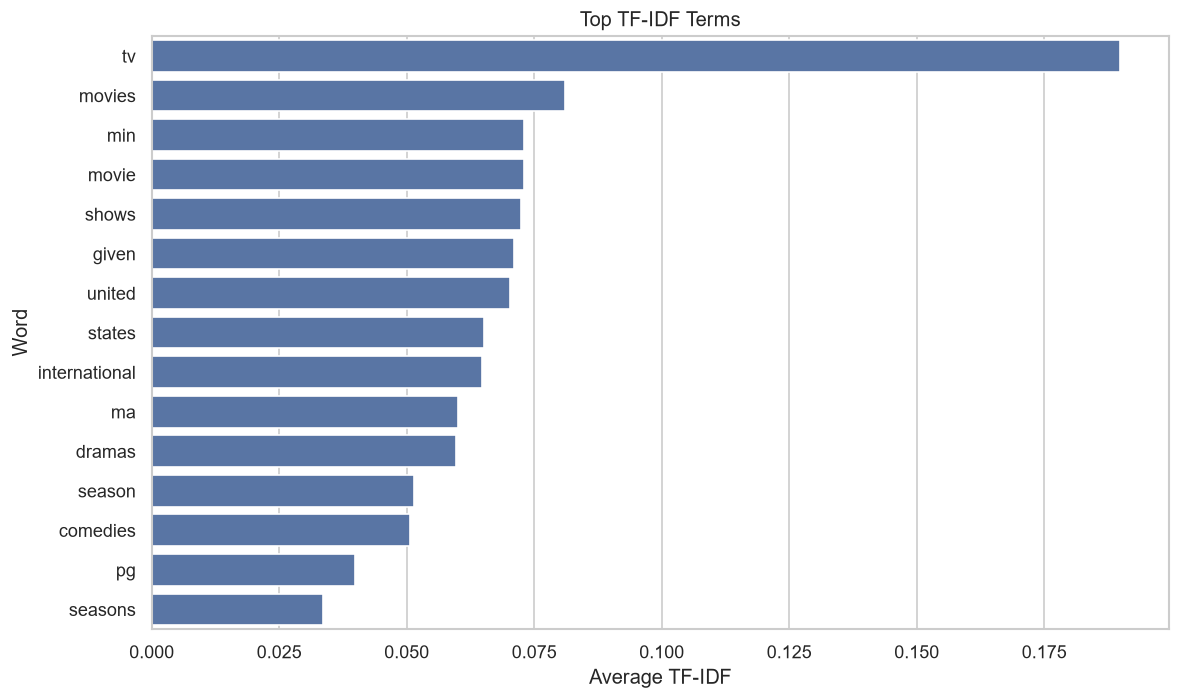

In [14]:
# ==========================================================
# CELL 14: FEATURE IMPORTANCE

print("=" * 70)
print("MOST IMPORTANT TF-IDF TERMS")
print("=" * 70)

weights = np.asarray(
    tfidf_matrix.mean(axis=0)
).flatten()

importance = pd.DataFrame({
    "Word": feature_names,
    "Average TF-IDF": weights
})

importance = importance.sort_values(
    by="Average TF-IDF",
    ascending=False
)

display(importance.head(20))

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(15),
    x="Average TF-IDF",
    y="Word"
)

plt.title("Top TF-IDF Terms")
plt.tight_layout()

plt.show()

In [15]:
# ==========================================================
# CELL 15: RECOMMENDATION EVALUATION

print("=" * 70)
print("RECOMMENDATION SYSTEM EVALUATION")
print("=" * 70)

coverage = (
    len(title_to_index) /
    len(working_df)
)

unique_titles = (
    working_df[title_column]
    .nunique()
)

average_similarity = (
    similarity_matrix.sum() -
    len(similarity_matrix)
) / (
    similarity_matrix.size -
    len(similarity_matrix)
)

genre_column = selected_columns.get("listed_in")

genre_diversity = (
    working_df[genre_column]
    .nunique()
    if genre_column else 0
)

print(f"Recommendation Coverage : {coverage:.2%}")
print(f"Unique Titles           : {unique_titles}")
print(f"Average Similarity      : {average_similarity:.4f}")
print(f"Genre Diversity         : {genre_diversity}")

print("\nEvaluation Summary")

print("- High coverage indicates most titles can be recommended.")
print("- TF-IDF provides metadata-driven similarity.")
print("- Cosine similarity captures semantic closeness.")
print("- Diverse genres improve recommendation quality.")

RECOMMENDATION SYSTEM EVALUATION
Recommendation Coverage : 99.90%
Unique Titles           : 8781
Average Similarity      : 0.1034
Genre Diversity         : 513

Evaluation Summary
- High coverage indicates most titles can be recommended.
- TF-IDF provides metadata-driven similarity.
- Cosine similarity captures semantic closeness.
- Diverse genres improve recommendation quality.


In [16]:
# ==========================================================
# CELL 16: ERROR HANDLING

print("=" * 70)
print("TESTING ERROR HANDLING")
print("=" * 70)

test_cases = [
    "",
    "Unknown Movie",
    None,
]

if title_column:
    duplicate_test = working_df[title_column].iloc[0]
    test_cases.append(duplicate_test)

for movie in test_cases:

    print("\nTesting:", movie)

    try:

        result = recommend_movies(movie)

        if isinstance(result, pd.DataFrame) and not result.empty:
            print("Recommendation generated successfully.")

    except Exception as error:

        print("Handled Exception:", error)

TESTING ERROR HANDLING

Testing: 
Movie title cannot be empty.

Testing: Unknown Movie
"Unknown Movie" not found in dataset.

Testing: None
Please provide a valid movie title.

Testing: Dick Johnson Is Dead
Recommendation generated successfully.


In [23]:
# ==========================================================
# CELL 17: INTERACTIVE RECOMMENDATION

print("=" * 70)
print("INTERACTIVE NETFLIX RECOMMENDATION SYSTEM")
print("=" * 70)

user_title = input("Enter a Netflix title: ").strip()

if user_title:
    recommendations = recommend_movies(user_title, top_n=10)

    if recommendations.empty:
        print("\nNo recommendations available.")
    else:
        print(f"\nTop Recommendations for '{user_title}'")
        display(recommendations)
else:
    print("No title entered.")

INTERACTIVE NETFLIX RECOMMENDATION SYSTEM


Enter a Netflix title:  Sunganges	



Top Recommendations for 'Sunganges'


,title,listed_in,Similarity Score
0,John & Jane,"Documentaries, International Movies",1.0000
1,Searching For Sheela,"Documentaries, International Movies",0.9361
2,1000 Rupee Note,"Dramas, International Movies",0.7400
3,​Maj Rati ​​Keteki,"Dramas, International Movies",0.7400
4,Red Oleanders Raktokarobi,"Dramas, International Movies",0.7400
5,Sarvopari Palakkaran,"Dramas, International Movies",0.7400
6,Limitless,"Documentaries, International Movies, Sports Movies",0.7365
7,Santa Banta Pvt Ltd,"Comedies, International Movies",0.7182
8,Yeh Ballet,"Dramas, International Movies",0.6864
9,The Sky Is Pink,"Dramas, International Movies",0.6864


VISUALIZATION DASHBOARD


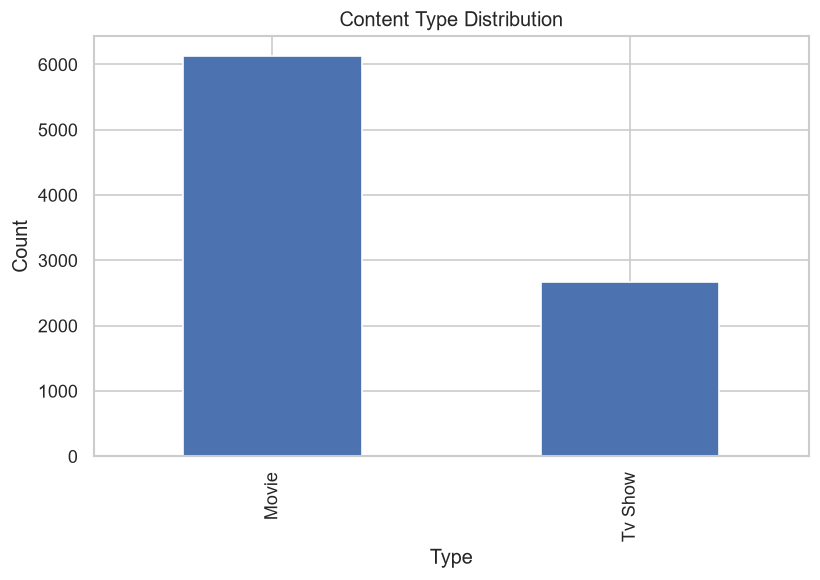

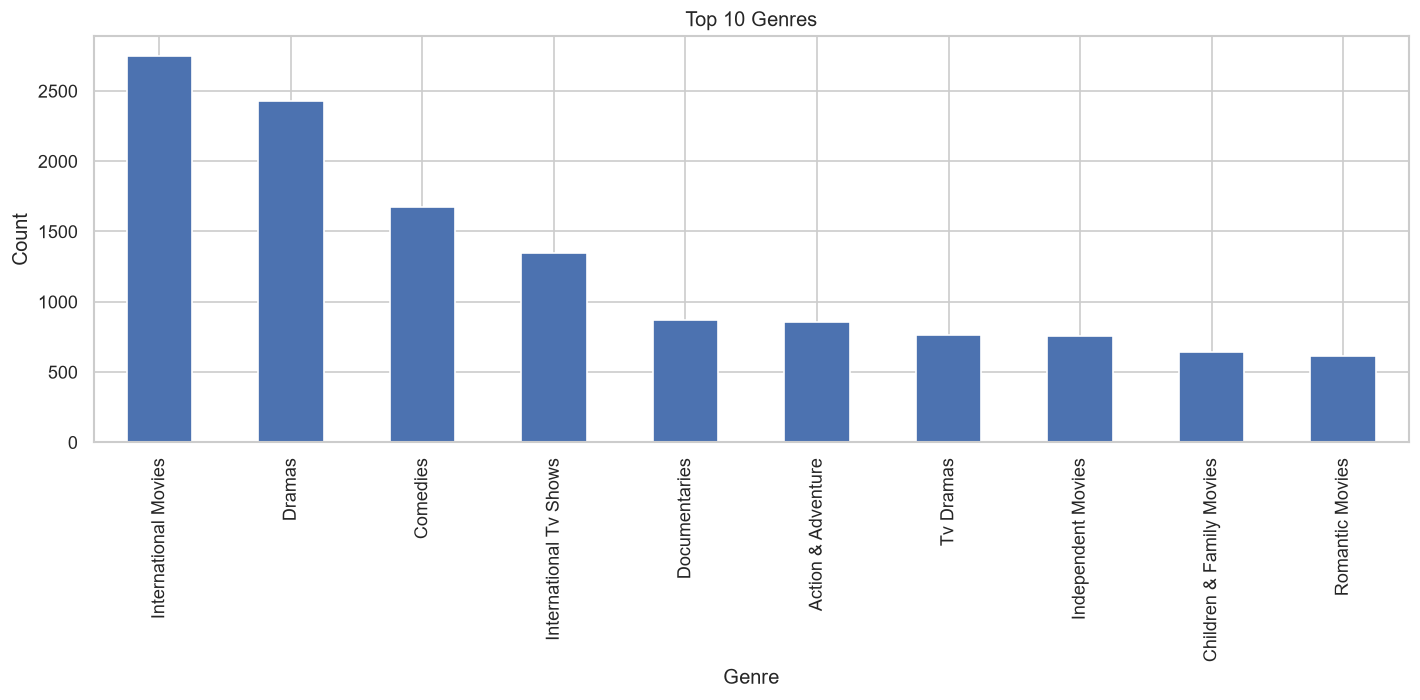

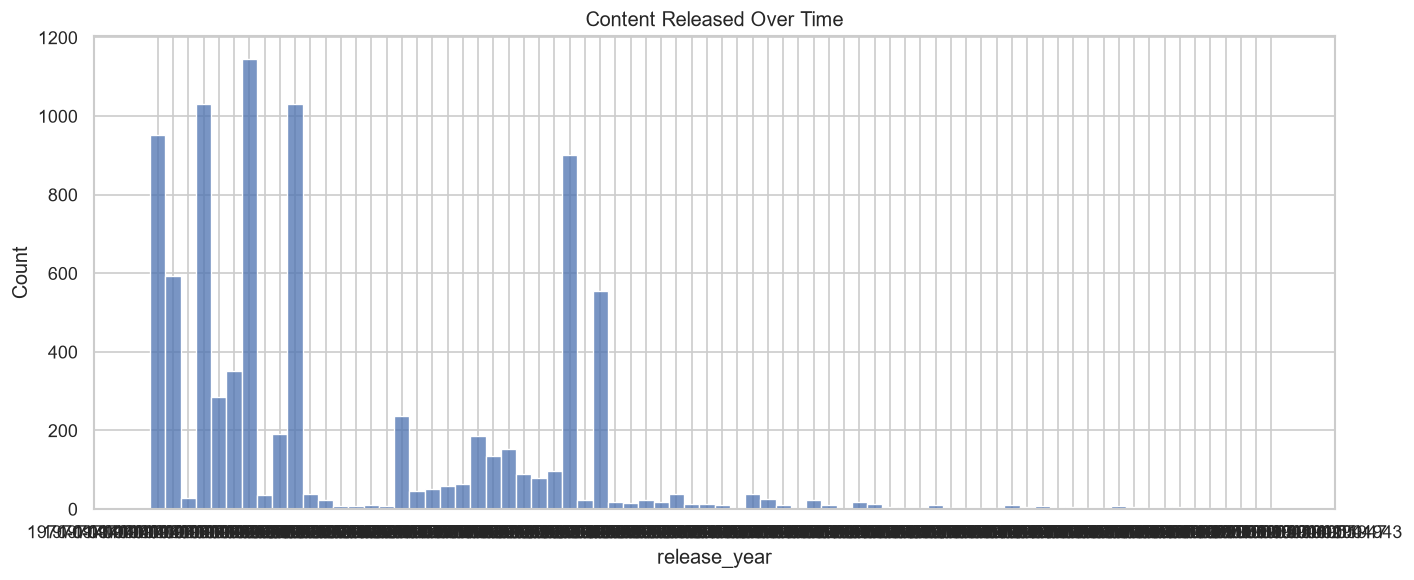

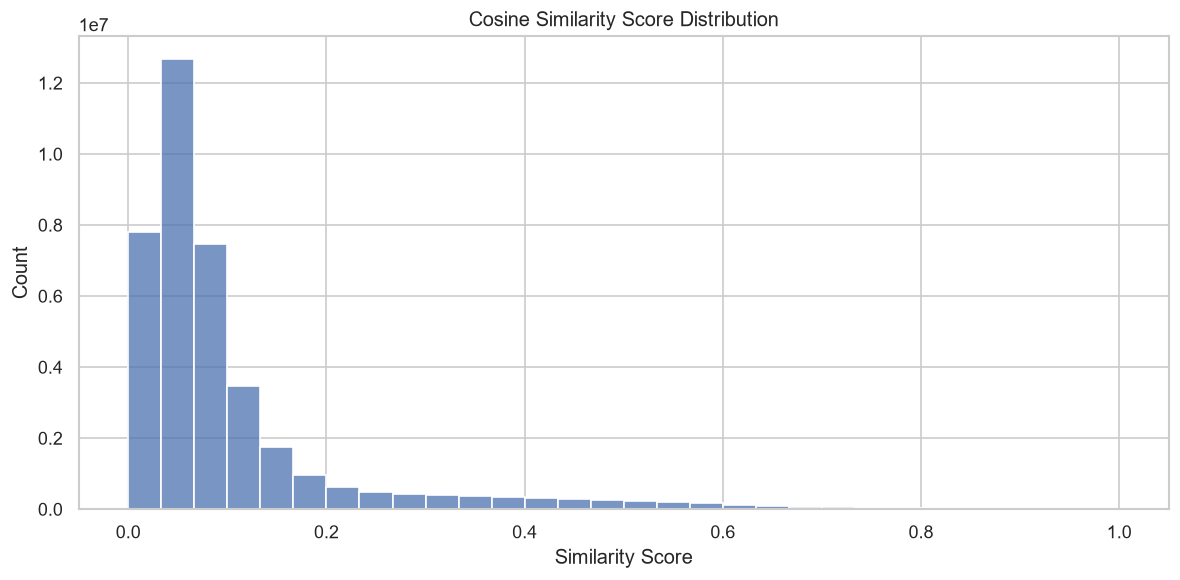

In [18]:
# ==========================================================
# CELL 18: VISUALIZATION DASHBOARD

print("=" * 70)
print("VISUALIZATION DASHBOARD")
print("=" * 70)

# -------------------------------
# Visualization 1 : Content Type
# -------------------------------

if selected_columns.get("type"):

    plt.figure(figsize=(7, 5))

    working_df[selected_columns["type"]].value_counts().plot(
        kind="bar"
    )

    plt.title("Content Type Distribution")
    plt.xlabel("Type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# -------------------------------
# Visualization 2 : Top Genres
# -------------------------------

if selected_columns.get("listed_in"):

    genres = (
        working_df[selected_columns["listed_in"]]
        .str.split(",")
        .explode()
        .str.strip()
    )

    plt.figure(figsize=(12, 6))

    genres.value_counts().head(10).plot(kind="bar")

    plt.title("Top 10 Genres")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# -------------------------------
# Visualization 3 : Release Year
# -------------------------------

if selected_columns.get("release_year"):

    plt.figure(figsize=(12, 5))

    sns.histplot(
        working_df[selected_columns["release_year"]],
        bins=25
    )

    plt.title("Content Released Over Time")
    plt.tight_layout()
    plt.show()

# -------------------------------
# Visualization 4 : Recommendation
# Score Distribution
# -------------------------------

scores = similarity_matrix[
    np.triu_indices_from(similarity_matrix, k=1)
]

plt.figure(figsize=(10, 5))

sns.histplot(scores, bins=30)

plt.title("Cosine Similarity Score Distribution")
plt.xlabel("Similarity Score")
plt.tight_layout()

plt.show()

In [19]:
# ==========================================================
# CELL 19: BUSINESS INSIGHTS

print("=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

if selected_columns.get("listed_in"):

    top_genres = (
        working_df[selected_columns["listed_in"]]
        .str.split(",")
        .explode()
        .str.strip()
        .value_counts()
        .head(5)
    )

    print("\nTop Genres")

    print(top_genres)

print("\nRecommendation Insights")

print("- Content-based filtering recommends titles with similar metadata.")
print("- Descriptions contribute significantly to similarity calculation.")
print("- Genres and cast improve recommendation relevance.")
print("- TF-IDF reduces the influence of common words.")
print("- Cosine Similarity effectively identifies related content.")

print("\nBusiness Value")

print("- Improves user engagement.")
print("- Increases watch time.")
print("- Enhances personalized content discovery.")
print("- Supports customer retention.")
print("- Can be extended into a production recommendation engine.")

BUSINESS INSIGHTS

Top Genres
listed_in
International Movies      2752
Dramas                    2426
Comedies                  1674
International Tv Shows    1349
Documentaries              869
Name: count, dtype: int64

Recommendation Insights
- Content-based filtering recommends titles with similar metadata.
- Descriptions contribute significantly to similarity calculation.
- Genres and cast improve recommendation relevance.
- TF-IDF reduces the influence of common words.
- Cosine Similarity effectively identifies related content.

Business Value
- Improves user engagement.
- Increases watch time.
- Enhances personalized content discovery.
- Supports customer retention.
- Can be extended into a production recommendation engine.


In [20]:
# ==========================================================
# CELL 20: PROJECT SUMMARY

print("=" * 70)
print("PROJECT SUMMARY")
print("=" * 70)

print(f"Dataset Size            : {df.shape}")
print(f"Movies Processed        : {len(working_df)}")
print(f"Vocabulary Size         : {len(feature_names)}")
print(f"Features Used           : {len(metadata_columns)}")
print("Similarity Method       : Cosine Similarity")
print("Recommendation Engine   : Content-Based Filtering")
print("Vectorization           : TF-IDF")
print("Machine Learning Model  : Scikit-Learn")
print("Project Status          : SUCCESS")

PROJECT SUMMARY
Dataset Size            : (8790, 18)
Movies Processed        : 8790
Vocabulary Size         : 5000
Features Used           : 7
Similarity Method       : Cosine Similarity
Recommendation Engine   : Content-Based Filtering
Vectorization           : TF-IDF
Machine Learning Model  : Scikit-Learn
Project Status          : SUCCESS


In [21]:
# ==========================================================
# CELL 21: SAVE OUTPUTS

print("=" * 70)
print("SAVING OUTPUT FILES")
print("=" * 70)

# Save recommendation sample

sample_title = working_df[title_column].iloc[0]

recommendations = recommend_movies(sample_title)

recommendations.to_csv(
    "recommendations.csv",
    index=False
)

print("Saved : recommendations.csv")

# Save similarity matrix sample

sample_size = min(50, len(working_df))

similarity_sample = pd.DataFrame(
    similarity_matrix[:sample_size, :sample_size],
    index=working_df[title_column].iloc[:sample_size],
    columns=working_df[title_column].iloc[:sample_size]
)

similarity_sample.to_csv(
    "similarity_matrix_sample.csv"
)

print("Saved : similarity_matrix_sample.csv")

print("\nAll outputs saved successfully.")

SAVING OUTPUT FILES
Saved : recommendations.csv
Saved : similarity_matrix_sample.csv

All outputs saved successfully.


In [22]:
# ==========================================================
# CELL 22: COMPLETION MESSAGE

print("=" * 60)
print("Task Completed Successfully")
print("=" * 60)

print("Task:")
print("Netflix Recommendation System Analysis\n")

print("Intern:")
print("Aarush Tyagi\n")

print("Organization:")
print("Auspify Technologies\n")

print("Status:")
print("Recommendation System Successfully Developed\n")

print("Algorithm:")
print("TF-IDF + Cosine Similarity\n")

print("Ready for Advanced Machine Learning")

print("=" * 60)
print("THANK YOU")
print("=" * 60)

Task Completed Successfully
Task:
Netflix Recommendation System Analysis

Intern:
Aarush Tyagi

Organization:
Auspify Technologies

Status:
Recommendation System Successfully Developed

Algorithm:
TF-IDF + Cosine Similarity

Ready for Advanced Machine Learning
THANK YOU
